In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [45]:
dataset=pd.read_csv('Datasets/exercise_angles.csv')
push_ups_dataset = dataset[(dataset['Label'] == 'Push Ups') & (dataset['Side'] == 'left')].copy()
push_ups_dataset.head()

,Side,Shoulder_Angle,Elbow_Angle,Hip_Angle,Knee_Angle,Ankle_Angle,Shoulder_Ground_Angle,Elbow_Ground_Angle,Hip_Ground_Angle,Knee_Ground_Angle,Ankle_Ground_Angle,Label
10206,left,93.284275,174.199804,136.237270,178.363132,128.837520,90.0,90.0,90.0,90.0,90.0,Push Ups
10207,left,92.756698,173.895349,137.451427,179.920415,129.659800,90.0,90.0,90.0,90.0,90.0,Push Ups
10208,left,92.173992,173.754503,138.530641,179.129101,130.124390,90.0,90.0,90.0,90.0,90.0,Push Ups
10209,left,91.883563,173.777313,139.195894,179.072117,129.905408,90.0,90.0,90.0,90.0,90.0,Push Ups
10210,left,91.885229,173.524345,139.578386,178.532254,129.964399,90.0,90.0,90.0,90.0,90.0,Push Ups


In [46]:
bicep_curl_dataset=pd.read_csv('Datasets/train_biceps.csv')
squat_dataset=pd.read_csv('Datasets/train_squat.csv')
plank_dataset=pd.read_csv('Datasets/train_plank.csv')
print(bicep_curl_dataset.head())

  label    nose_x    nose_y    nose_z    nose_v  left_shoulder_x  \
0     C  0.549027  0.320492 -0.175574  0.992889         0.488670   
1     C  0.540332  0.304887 -0.168256  0.993201         0.488359   
2     C  0.538717  0.301112 -0.178058  0.994154         0.487443   
3     C  0.537699  0.300658 -0.186825  0.994999         0.486305   
4     C  0.536932  0.298658 -0.206978  0.995858         0.485906   

   left_shoulder_y  left_shoulder_z  left_shoulder_v  right_shoulder_x  ...  \
0         0.342995         0.132471         0.990275          0.492497  ...   
1         0.341853         0.139501         0.990031          0.481190  ...   
2         0.341226         0.142286         0.990501          0.479147  ...   
3         0.340976         0.138553         0.991070          0.478530  ...   
4         0.340850         0.136672         0.991733          0.478530  ...   

   left_wrist_z  left_wrist_v  left_hip_x  left_hip_y  left_hip_z  left_hip_v  \
0      0.061884      0.027825    0.


Data exploration


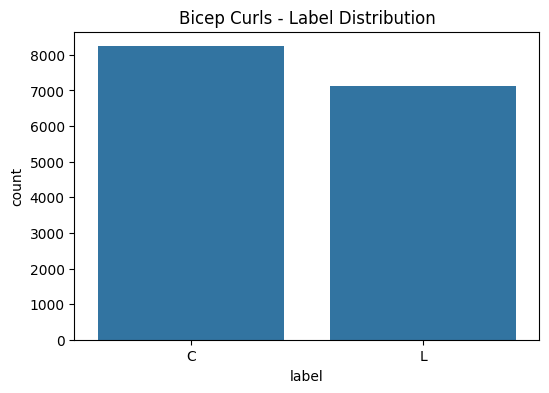

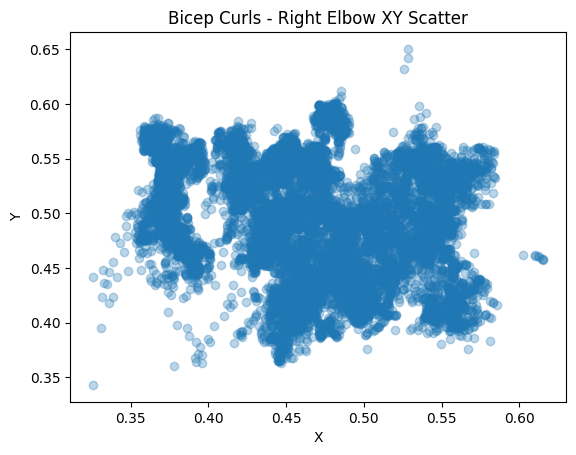

In [47]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=bicep_curl_dataset)
plt.title("Bicep Curls - Label Distribution")
plt.show()



plt.scatter(bicep_curl_dataset['right_elbow_x'], bicep_curl_dataset['right_elbow_y'], alpha=0.3)
plt.title("Bicep Curls - Right Elbow XY Scatter")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


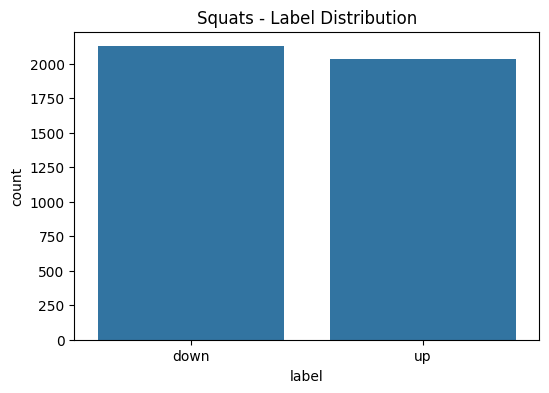

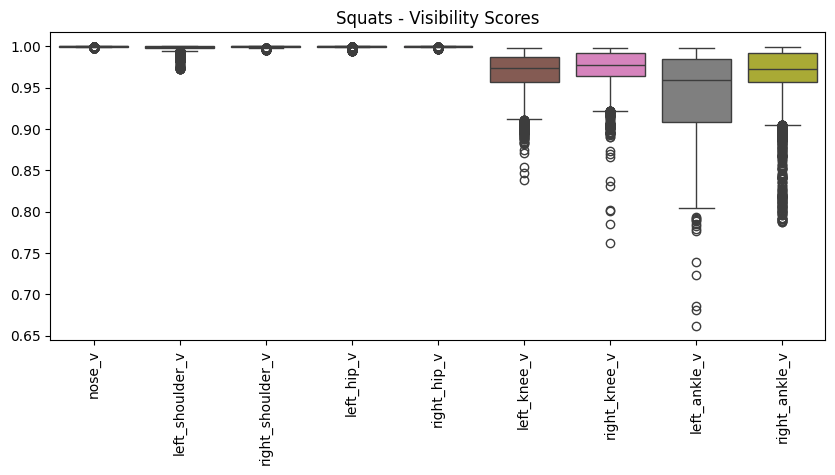

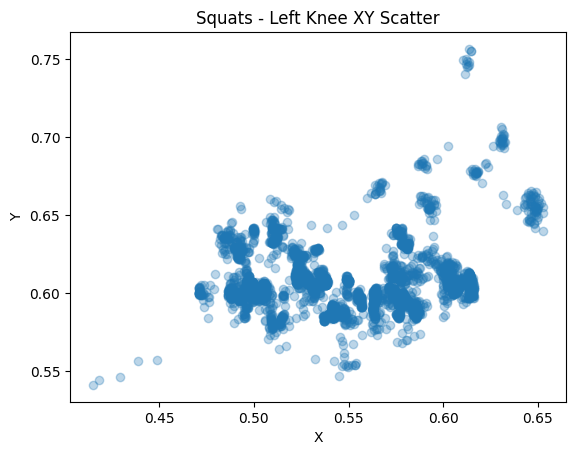

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=squat_dataset)
plt.title("Squats - Label Distribution")
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(data=squat_dataset.filter(like='_v'))
plt.title("Squats - Visibility Scores")
plt.xticks(rotation=90)
plt.show()

plt.scatter(squat_dataset['left_knee_x'], squat_dataset['left_knee_y'], alpha=0.3)
plt.title("Squats - Left Knee XY Scatter")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

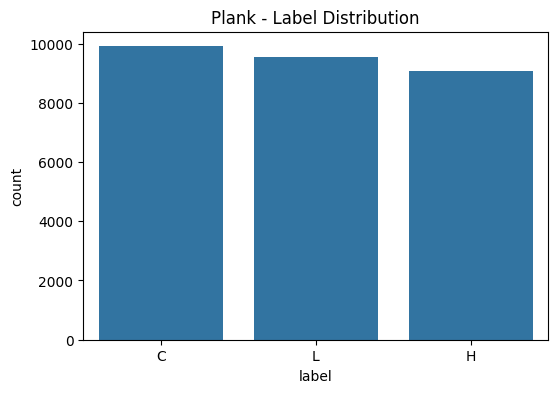

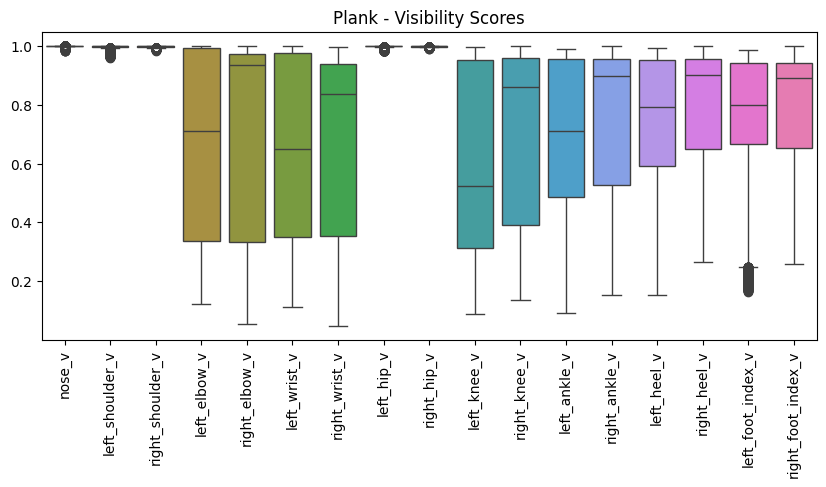

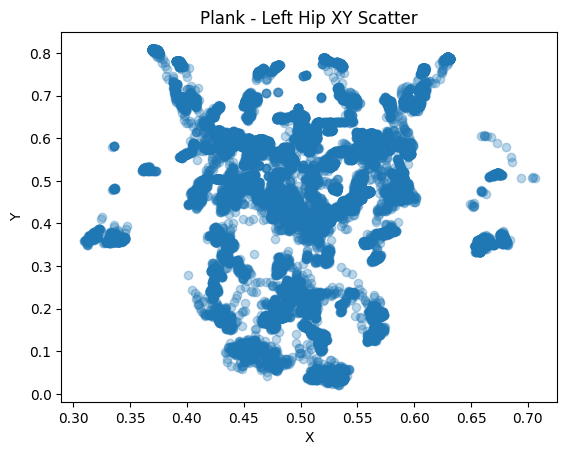

In [49]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=plank_dataset)
plt.title("Plank - Label Distribution")
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(data=plank_dataset.filter(like='_v'))
plt.title("Plank - Visibility Scores")
plt.xticks(rotation=90)
plt.show()

plt.scatter(plank_dataset['left_hip_x'], plank_dataset['left_hip_y'], alpha=0.3)
plt.title("Plank - Left Hip XY Scatter")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

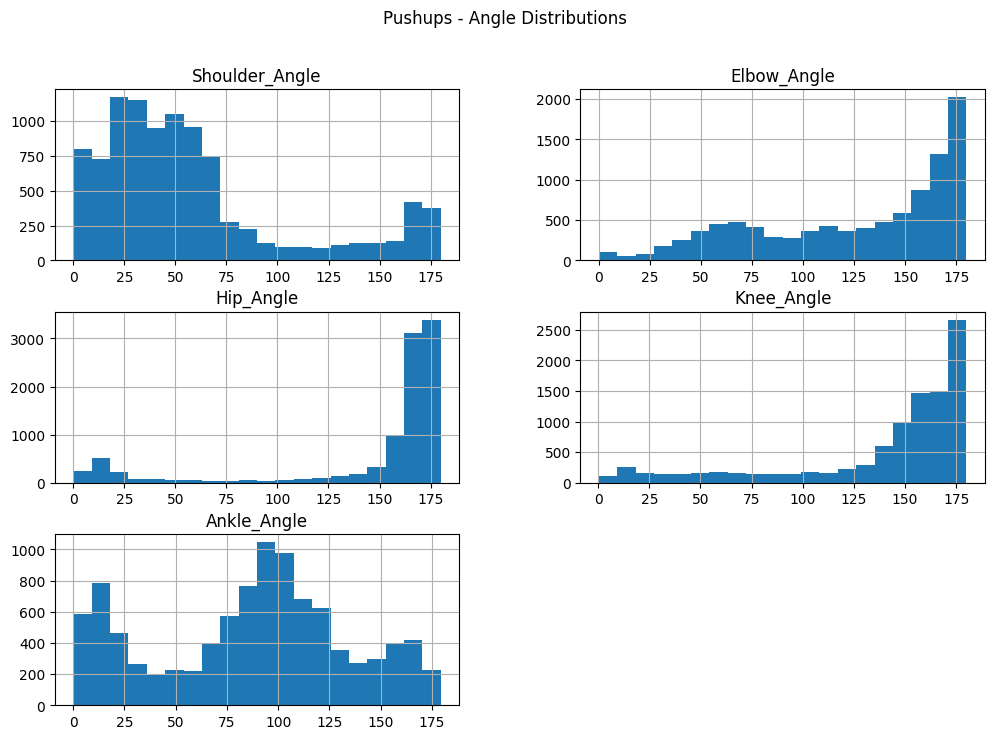

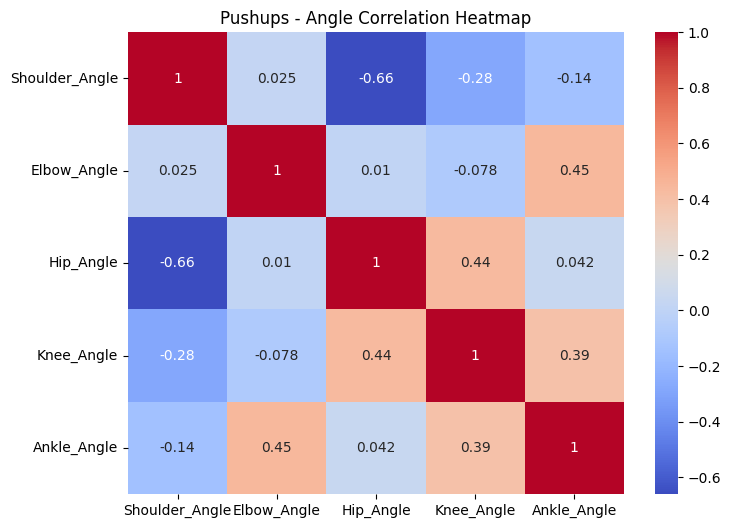

In [50]:
angle_cols = ['Shoulder_Angle', 'Elbow_Angle', 'Hip_Angle', 
              'Knee_Angle', 'Ankle_Angle']

# Histograms
push_ups_dataset[angle_cols].hist(bins=20, figsize=(12,8))
plt.suptitle("Pushups - Angle Distributions")
plt.show()


# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(push_ups_dataset[angle_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Pushups - Angle Correlation Heatmap")
plt.show()

Push Ups dataset pre processing

In [51]:
push_ups_dataset[push_ups_dataset['Side']=='left']['Ankle_Angle'].size

9764

In [52]:
push_ups_dataset['Form_Label'] = 'C'
angle_cols = ['Shoulder_Angle', 'Elbow_Angle', 'Hip_Angle', 
              'Knee_Angle', 'Ankle_Angle',
              'Shoulder_Ground_Angle', 'Elbow_Ground_Angle', 
              'Hip_Ground_Angle', 'Knee_Ground_Angle', 
              'Ankle_Ground_Angle']

min_vals = push_ups_dataset[angle_cols].min()
max_vals = push_ups_dataset[angle_cols].max()

lower_bounds = min_vals * 0.9
upper_bounds = max_vals * 1.1

#Data Augmentation
n_wrong = int(0.2 * len(push_ups_dataset))
wrong_samples = []
for _ in range(n_wrong):
    row = []
    for col in angle_cols:
        if np.random.rand() < 0.5:
            # value smaller than lower bound
            val = lower_bounds[col] - np.random.uniform(5, 15)
        else:
            # value larger than upper bound
            val = upper_bounds[col] + np.random.uniform(5, 15)
        row.append(val)
    wrong_samples.append(row)

# Create wrong Dataframe
wrong_df = pd.DataFrame(wrong_samples, columns=angle_cols)
wrong_df['Side'] = 'Left'
wrong_df['Label'] = 'Push Ups'
wrong_df['Form_Label'] = 'L'

# Step 3: Combine with correct dataset
final_df = pd.concat([push_ups_dataset, wrong_df], ignore_index=True)

final_df.head()


,Side,Shoulder_Angle,Elbow_Angle,Hip_Angle,Knee_Angle,Ankle_Angle,Shoulder_Ground_Angle,Elbow_Ground_Angle,Hip_Ground_Angle,Knee_Ground_Angle,Ankle_Ground_Angle,Label,Form_Label
0,left,93.284275,174.199804,136.237270,178.363132,128.837520,90.0,90.0,90.0,90.0,90.0,Push Ups,C
1,left,92.756698,173.895349,137.451427,179.920415,129.659800,90.0,90.0,90.0,90.0,90.0,Push Ups,C
2,left,92.173992,173.754503,138.530641,179.129101,130.124390,90.0,90.0,90.0,90.0,90.0,Push Ups,C
3,left,91.883563,173.777313,139.195894,179.072117,129.905408,90.0,90.0,90.0,90.0,90.0,Push Ups,C
4,left,91.885229,173.524345,139.578386,178.532254,129.964399,90.0,90.0,90.0,90.0,90.0,Push Ups,C


In [53]:
final_df['Form_Label'].value_counts()

Form_Label
C    9764
L    1952
Name: count, dtype: int64

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

X = final_df.drop(columns=['Side', 'Label', 'Form_Label'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
final_scaled = pd.concat([X_scaled, final_df[['Form_Label']]], axis=1)

final_scaled['Form_Label'] = np.where(final_scaled['Form_Label'] == 'C', 1, 0)

train_df, test_df = train_test_split(final_scaled, test_size=0.2, random_state=42, stratify=final_scaled['Form_Label'])

In [55]:
train_df.head()

,Shoulder_Angle,Elbow_Angle,Hip_Angle,Knee_Angle,Ankle_Angle,Shoulder_Ground_Angle,Elbow_Ground_Angle,Hip_Ground_Angle,Knee_Ground_Angle,Ankle_Ground_Angle,Form_Label
3936,-0.982157,-0.452735,0.476274,0.321954,-0.315467,-0.007292,0.008978,0.274816,0.268857,0.272877,1
4921,-0.688277,-0.054853,0.535327,0.351853,-0.085543,-0.007292,0.008978,0.274816,0.268857,0.272877,1
11358,-1.140400,-2.128048,-2.218088,1.113355,-1.511977,-2.802477,-2.247337,-3.250256,-3.303900,0.644869,0
6435,0.478877,0.159451,0.463670,0.468720,0.626489,-0.007292,0.008978,0.274816,0.268857,0.272877,1
7702,0.350325,-0.240064,0.238479,-1.518489,-0.631264,-0.007292,0.008978,0.274816,0.268857,0.272877,1


In [56]:
# Save to CSV
train_df.to_csv('Datasets/train_push_ups.csv', index=False)
test_df.to_csv('Datasets/test_push_ups.csv', index=False)

In [57]:
print("Preprocessing complete. Train and test files saved.")

Preprocessing complete. Train and test files saved.
